# Lineage-Stratified Expression Scoring

Given a gene, rank every cell line by how unusual its expression is —
**within its own lineage**, and **weighted by how many sources agree**.

## Why not just compare against all cell lines

Expression is tissue-specific. Pooling every lineage mixes populations where a
gene is on with populations where it is off, so a line can rank in the top 10%
of the panel purely because other tissues don't express the gene. That is a fact
about panel composition, not about the cell line.

Real example from this data: EGFR has a pooled median of 4.15 but a median of
1.13 in skin. A melanoma line at 10.53 scores `robust_z = 2.66` pooled and
**6.30 within skin** — pooled, Tukey doesn't even flag it as an outlier.

## Why not just average the three sources

Averaging throws away the information that matters most: **how many independent
datasets agree**. A small deviation seen consistently in three sources is
stronger evidence than a large one seen once — that is precision, not effect
size, and averaging cannot express it.

| line | evidence | mean z | combined Z |
|---|---|---|---|
| A | 3 sources, all z = 1.5 | 1.50 | **2.60** |
| B | 1 source, z = 2.6 | 2.60 | 2.60 |
| C | 3 sources: 2.6, 0.1, −0.3 | 0.80 | 1.39 |

Stouffer's method gives A the same weight as B despite a much smaller per-source
effect, and correctly deflates C where the sources disagree.

## The method

| step | statistic | what it handles |
|---|---|---|
| 1 | robust z (median / MAD) within lineage | effect size, not inflated by the outlier itself |
| 2 | empirical p (rank-based) | no distributional assumption |
| 3 | Stouffer combination, weighted by √n_samples | rewards replication; detects small consistent deviations |
| 4 | Cochran's Q / I² | flags sources that disagree |
| 5 | empirical-Bayes shrinkage `z·k/(k+1)` | stops unreplicated extremes topping the ranking |
| 6 | Benjamini–Hochberg FDR | ~1,500 lines tested at once for one gene |

**Nothing is dropped.** Lines in lineages with few peers, lines with unknown
lineage, and single-source lines are all scored and **flagged**, never removed.

## References

- **Stouffer et al. (1949)**, *The American Soldier*. Origin of the weighted
  z-combination; still the standard for combining independent evidence.
- **Higgins & Thompson (2002)**, *Quantifying heterogeneity in a meta-analysis*,
  Stat Med 21:1539. Source of I² and the >50% conventional cut.
- **Benjamini & Hochberg (1995)**, *Controlling the false discovery rate*,
  JRSS-B 57:289.
- **Leys et al. (2013)**, *Detecting outliers: do not use standard deviation
  around the mean*, J Exp Soc Psychol 49(4):764. MAD over SD.
- **Isella et al. (2024)**, Mol Oncol, PMC11161737. Gene-specific expression
  outlier calling in cell line panels.
- **Efron & Morris (1975)**, *Data analysis using Stein\'s estimator*, JASA
  70:311. The shrinkage rationale.

In [1]:
import numpy as np
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 170)
plt.rcParams.update({"figure.dpi": 110})

DB_PATH = "celllineselector.db"
con = duckdb.connect(DB_PATH, read_only=True)

# Below this many peers the lineage statistics are unstable. Lines are FLAGGED,
# never dropped — small lineages are still real cell lines.
MIN_PEERS_FOR_LINEAGE = 15

EXPRESSED_MIN  = 1.0    # log2 units; HPA-style detection floor
PRIOR_STRENGTH = 1.0    # shrinkage aggressiveness: k/(k+prior)
I2_CUT         = 50     # above this, sources are judged to disagree

# --- guards on the z-score denominator (see section 2.1) ---
MAD_FLOOR       = 0.1   # caps z where spread is small but non-zero
MIN_PEERS_FOR_Z = 3     # below this a lineage has no distribution at all
SILENT_FRAC     = 0.20  # gene off in >80% of a lineage -> z is meaningless

# --- tissue specificity (HPA / Yanai conventions) ---
HPA_FOLD   = 5.0    # HPA's 5-fold rule for enriched / enhanced
DELTA_CUT  = 0.5    # Cliff's delta: 'medium or larger'
TAU_BROAD, TAU_SPECIFIC = 0.30, 0.60

# Must not collide with DepMap's own literal "unknown" lineage label, or
# genuinely-unknown lines get pooled with lines that have no label at all.
NO_LINEAGE      = "(no lineage recorded)"

# Sources allowed to vote on whether a gene is SILENT in a lineage. A source
# with a detection floor cannot distinguish "not expressed" from "below
# detection", so it must be excluded from that judgement. Set empirically by
# source_floor_check() in section 1.1 — do not hardcode without running it.
SILENT_SOURCES  = ["depmap_expr", "hpa_rna"]
FLOOR_FRAC_LOW  = 0.02   # <2% of values below EXPRESSED_MIN => suspect a floor

# Sources permitted to compute TISSUE SPECIFICITY. Same exclusion, same reason:
# a floored source lifts every silent tissue to background, compressing the
# ratio tau depends on. Observed: GEO tau 0.666 vs DepMap 0.748 / HPA 0.741 on
# identical biology.
TAU_SOURCES = ["depmap_expr", "hpa_rna"]

## 1. Fetch expression for one gene

One row per (source, cell line), all three sources on `log2(x+1)`, GEO collapsed
to a median with `n_samples` retained as a precision weight.

In [2]:
def cols_of(con, t):
    return [r[0] for r in con.execute(f'DESCRIBE "{t}"').fetchall()]

def table_exists(con, t):
    return con.execute("SELECT count(*) FROM information_schema.tables "
                       "WHERE lower(table_name)=?", [t.lower()]).fetchone()[0] > 0

def has_col(con, t, c):
    return table_exists(con, t) and c in cols_of(con, t)

def resolve_gene(con, gene):
    """Accepts an ENSG id or ANY name/alias, in any case."""
    g = str(gene).strip().lower()
    if g.startswith("ensg"):
        q = "SELECT gene_id, gene_names, uniprot_ids, hugo_symbol FROM gene WHERE gene_id = ?"
    else:
        q = ("SELECT gene_id, gene_names, uniprot_ids, hugo_symbol FROM gene "
             "WHERE list_contains(list_transform(gene_names, x -> lower(x)), ?)")
    row = con.execute(q, [g]).fetchone()
    if row is None:
        raise ValueError(f"'{gene}' not found in gene table (as id or name)")
    return row[0], list(row[1] or []), list(row[2] or []), row[3]

def lineage_map(con, table="sample_info", col="lineage"):
    d = con.execute(f'SELECT model_id, "{col}" AS lineage FROM "{table}" '
                    f'WHERE "{col}" IS NOT NULL').df()
    return d.drop_duplicates("model_id").set_index("model_id")["lineage"]

def fetch_gene_expression(con, gene, log_geo=True, log_hpa=True, verbose=True):
    """
    All expression values for one gene, one row per (source, cell line).

    GEO holds several GSM samples per line, so it is collapsed to a median and
    n_samples carried forward as a precision weight. GEO and HPA are raw
    TPM/nTPM while DepMap is log2(TPM+1) — without the transform the sources
    are not comparable.
    """
    gid, gnames, _, hugo = resolve_gene(con, gene)
    frames = []

    if has_col(con, "depmap_expr", gid):
        d = con.execute(f'SELECT model_id, "{gid}" AS value FROM depmap_expr '
                        f'WHERE "{gid}" IS NOT NULL').df()
        d["n_samples"] = 1; d["source"] = "depmap_expr"; frames.append(d)

    if has_col(con, "geo_expr", gid):
        d = con.execute(f'SELECT model_id, median("{gid}") AS value, count(*) AS n_samples '
                        f'FROM geo_expr WHERE "{gid}" IS NOT NULL GROUP BY model_id').df()
        if log_geo: d["value"] = np.log2(d["value"].clip(lower=0) + 1)
        d["source"] = "geo_expr"; frames.append(d)

    vcol = next((c for c in ("ntpm","ptpm","tpm") if has_col(con,"hpa_rna",c)), None)
    if vcol:
        d = con.execute(f'SELECT model_id, avg("{vcol}") AS value, count(*) AS n_samples '
                        f'FROM hpa_rna WHERE lower(gene)=? GROUP BY model_id', [gid]).df()
        if log_hpa: d["value"] = np.log2(d["value"].clip(lower=0) + 1)
        d["source"] = "hpa_rna"; frames.append(d)

    df = pd.concat(frames, ignore_index=True)
    df["lineage"] = df["model_id"].map(lineage_map(con))
    if verbose:
        print(f"{gene} -> {gid} ({hugo or ', '.join(gnames)})")
        print(df.groupby("source").agg(n_lines=("model_id","nunique"),
              median=("value","median"), min=("value","min"),
              max=("value","max")).round(2).to_string())
        print(f"\nlineages: {df.lineage.nunique()} | "
              f"lines with no lineage: {df.loc[df.lineage.isna(),'model_id'].nunique()}")
    return df, gid

### 1.1 Do all three sources measure on the same footing?

The three sources are not just differently *scaled* — they are differently
*measured*. DepMap and HPA are RNA-seq (TPM-derived, genuinely reaching zero).
GEO is an archive, not a pipeline: each series carries whatever its submitter
uploaded, and much of it is microarray.

**Why this matters, and why it matters less than it first appears.**

RMA-normalised microarray data floors at background — typically log2 3–6 —
because no probe can read below the fitted background. RNA-seq reaches 0. So a
floored source reports background as signal and **cannot distinguish "not
expressed" from "below detection"**.

But the score is a z computed *within source and within lineage*, which is
unitless. A cell line 2.3 MADs above its lineage median scores 2.315 whether
measured by sequencing or by array — the floor cancels. Verified directly:
identical z from both technologies on the same underlying biology.

So the floor breaks exactly one thing: **judging whether a gene is off**. That
is why floored sources are excluded from `SILENT_SOURCES` and nothing else
changes.

The check below detects the floor from the data rather than assuming it.

In [3]:
def source_floor_check(df, expressed_min=EXPRESSED_MIN, floor_frac=FLOOR_FRAC_LOW):
    """
    Detect a detection floor per source.

    A source whose minimum sits well above zero AND which reports essentially
    no low values has a floor: it is reporting background as signal. Such a
    source cannot judge whether a gene is off, and is excluded from
    SILENT_SOURCES.

    RNA-seq TPM genuinely reaches 0; RMA-normalised microarray floors at the
    fitted background, typically log2 3-6. The signature is a hard minimum with
    zero mass below it.
    """
    rows = []
    for src, g in df.groupby("source"):
        v = g["value"].dropna()
        frac_low = (v < expressed_min).mean()
        rows.append({"source": src, "n": len(v),
                     "min": round(v.min(), 3), "p01": round(v.quantile(.01), 3),
                     "frac_below_1": round(frac_low, 4),
                     "floored": bool(v.min() > expressed_min and frac_low < floor_frac)})
    out = pd.DataFrame(rows)
    floored = out.loc[out.floored, "source"].tolist()
    print(out.to_string(index=False))
    if floored:
        print(f"\nFLOORED: {', '.join(floored)} — excluded from silent-lineage judgements.")
        print("  These sources cannot distinguish 'not expressed' from 'below detection'.")
        print(f"  Their z-scores remain valid: z is computed within source, so the")
        print(f"  floor cancels. Only the silence judgement is affected.")
    else:
        print("\nno floored sources detected — all may vote on silence")
    return out, [s for s in out.source if s not in floored]

## 2. The statistical components

Each is small and independently testable. Together they form the score.

### 2.1 Guarding the z-score denominator

A z-score divides by spread. When spread collapses, the score explodes and
becomes meaningless — the number reports the missing denominator, not the
biology. Three situations cause this here, all observed in the real data:

| situation | example | why z fails |
|---|---|---|
| **too few peers** | `adrenal_cortex`, n=1 | one value has no spread; MAD = 0 by definition |
| **gene silent in lineage** | EGFR in `blood`: n=104, median 0.12, 38% at zero | the gene is simply off in that tissue; any expression scores z = 16+ |
| **no spread** | MAD exactly 0 with adequate n | every line reads identically |

**A MAD floor alone does not fix the silent case.** Blood's MAD is 0.178 —
comfortably above any sensible floor — while the distribution is still
degenerate. The silent-lineage check is a separate guard, and it is the one
that matters.

These lines are **flagged, not dropped**. They carry `verdict =
"insufficient data (...)"` with the reason attached, and section 5.2 reports
them separately — because a gene firing in a tissue where it is normally
silent is arguably a *stronger* finding than the same gene being high in a
tissue where it is already high. It simply cannot be expressed as a z-score.

In [4]:
MIN_PEERS_FOR_LINEAGE = 15   # below this, lineage stats are unstable -> flagged, NOT dropped

def robust_z(x, v, mad_floor=MAD_FLOOR, min_n=MIN_PEERS_FOR_Z,
             expressed_min=EXPRESSED_MIN, silent_frac=SILENT_FRAC):
    """
    (x - median) / MAD within a lineage. Returns (z, reason).

    z is NaN whenever the reference distribution cannot support one, and
    `reason` names which guard fired. Three guards, each for a real situation
    seen in this data:

      "too few peers"          n < 3. MAD is 0 by construction, not because
                               the lines agree. e.g. adrenal_cortex, n=1.

      "gene silent in lineage" the gene is off across the lineage — median
                               near 0, most lines at zero. A line with any
                               expression then scores z = 16+, which measures
                               the ABSENCE of a denominator, not a real
                               effect. e.g. EGFR in blood: n=104, median 0.12,
                               38% at exactly zero.

                               A MAD floor alone does NOT catch this. Blood's
                               MAD is 0.178 — above any sensible floor — while
                               the distribution is still degenerate. This
                               guard is the one that matters.

      "no spread"              MAD is exactly 0 despite adequate n.

    Lines suppressed here are not dropped; they surface with
    verdict = "insufficient data" and the reason attached, and are reported
    separately in section 5.2.
    """
    v = np.asarray(v, float)
    if len(v) < min_n:
        return np.nan, "too few peers"
    if (v > expressed_min).mean() < silent_frac:
        return np.nan, "gene silent in lineage"
    mad = stats.median_abs_deviation(v, scale="normal")
    if mad <= 0:
        return np.nan, "no spread"
    return (x - np.median(v)) / max(mad, mad_floor), "ok"

def empirical_p(x, v, tail="two"):
    v = np.asarray(v); n = len(v)
    hi = ((v >= x).sum()+1)/(n+1); lo = ((v <= x).sum()+1)/(n+1)
    return min(1.0, 2*min(hi,lo)) if tail=="two" else (hi if tail=="hi" else lo)

def stouffer(zs, weights=None):
    z = np.asarray([v for v in zs if np.isfinite(v)], float)
    if not len(z): return np.nan, np.nan, 0
    w = np.ones(len(z)) if weights is None else np.asarray(
        [w for w,v in zip(weights,zs) if np.isfinite(v)], float)
    Z = (w*z).sum()/np.sqrt((w**2).sum())
    return Z, 2*(1-stats.norm.cdf(abs(Z))), len(z)

def heterogeneity(zs):
    z = np.asarray([v for v in zs if np.isfinite(v)], float); k=len(z)
    if k < 2: return np.nan, np.nan, np.nan
    Q = ((z-z.mean())**2).sum()
    return Q, 1-stats.chi2.cdf(Q,k-1), (max(0,(Q-(k-1))/Q)*100 if Q>0 else 0.0)

def shrink(z, k, prior_strength=1.0):
    return z * k/(k+prior_strength) if np.isfinite(z) else np.nan

def score_gene_lineage(df, min_peers=MIN_PEERS_FOR_LINEAGE, expressed_min=EXPRESSED_MIN,
                       weight_by_samples=True, prior_strength=1.0,
                       replicate_warn=1.0, silent_sources=None, verbose=True):
    """
    Rank every cell line for one gene WITHIN its lineage, combining sources by
    meta-analysis.

    NOTHING is dropped. Lines in small lineages, lines with no lineage label,
    single-source lines, and lines whose lineage does not express the gene are
    all scored where possible and FLAGGED where not.

    silent_sources : sources permitted to judge whether a gene is off. A source
        with a detection floor reports background as signal and cannot tell
        "not expressed" from "below detection". Set this from
        source_floor_check() rather than assuming. Note the z-scores of a
        floored source remain valid — z is computed within source, so the floor
        cancels; only the silence judgement is affected.

    Replicate handling
    ------------------
    A cell line can have several DepMap profiles — separate sequencing runs of
    the same line, each with its own profileid. These are technical replicates,
    not independent evidence:
      * keeping one arbitrarily would discard a real measurement
      * counting them as two sources would inflate the Stouffer combination,
        which assumes sources are INDEPENDENT
    So replicates are collapsed to a median and n_samples is summed — the extra
    profile counts as precision (weight sqrt(2)), not as a second source.
    Replicates differing by more than `replicate_warn` log2 units are reported:
    that is a misidentification signal, not technical variation.

    Returns (summary_df, per_source_df).
    """
    sil_src = silent_sources if silent_sources is not None else SILENT_SOURCES
    d = df.dropna(subset=["value"]).copy()
    # NO_LINEAGE rather than "unknown": DepMap uses "unknown" as a real label,
    # and pooling those with unlabelled lines builds one group from two
    # different situations.
    d["lineage"] = d["lineage"].fillna(NO_LINEAGE)
    if "n_samples" not in d.columns:
        d["n_samples"] = 1

    dup_mask = d.duplicated(["model_id", "source"], keep=False)
    if dup_mask.any():
        dups = d[dup_mask]
        rng_ = dups.groupby(["model_id", "source"])["value"].agg(["min", "max"])
        rng_["range"] = rng_["max"] - rng_["min"]
        if verbose:
            print(f"  {int(dup_mask.sum()):,} rows are replicate profiles of "
                  f"{dups.model_id.nunique():,} cell lines "
                  f"(max within-line range {rng_['range'].max():.2f} log2)")
        suspect = rng_[rng_["range"] > replicate_warn]
        if len(suspect) and verbose:
            print(f"  WARNING: {len(suspect)} line(s) have replicates differing by "
                  f">{replicate_warn} log2 — possible misidentification, not replication")

    d = (d.groupby(["model_id", "source", "lineage"], as_index=False)
           .agg(value=("value", "median"), n_samples=("n_samples", "sum")))

    recs = []
    for (src, lin), g in d.groupby(["source", "lineage"]):
        v = g["value"].to_numpy()
        expressed = v[v > expressed_min]
        small = len(v) < min_peers
        for _, r in g.iterrows():
            z, why = robust_z(r.value, v, expressed_min=expressed_min)
            recs.append({"model_id": r.model_id, "source": src, "lineage": lin,
                         "value": r.value, "n_peers": len(v), "small_lineage": small,
                         "lineage_median": np.median(v), "z": z, "z_reason": why,
                         "pct_expressed": (np.mean(expressed < r.value) * 100
                                           if len(expressed) else np.nan),
                         "p_emp": empirical_p(r.value, v),
                         "n_samples": r.n_samples,
                         "frac_expressed": float((v > expressed_min).mean())})
    per = pd.DataFrame(recs)

    out = []
    for mid, g in per.groupby("model_id"):
        zs = g.z.tolist()
        w = np.sqrt(g.n_samples.astype(float)).tolist() if weight_by_samples else None
        Z, p, k = stouffer(zs, w)
        Q, pq, I2 = heterogeneity(zs)
        ps = g.p_emp.dropna().to_numpy()
        fisher_p = (stats.combine_pvalues(ps, method="fisher")[1] if len(ps) > 1
                    else (ps[0] if len(ps) else np.nan))
        gs = g[g.source.isin(sil_src)]
        out.append({"model_id": mid, "lineage": g.lineage.iloc[0],
                    "z_reasons": "; ".join(sorted(set(g.z_reason))),
                    # Only unfloored sources vote on silence, and .all() rather
                    # than .any(): a lineage can be silent in one source and
                    # expressed in another, and one source must not condemn the
                    # line on its own.
                    "lineage_silent": bool(len(gs) and
                        (gs.frac_expressed < SILENT_FRAC).all()),
                    "lineage_silent_any": bool((g.frac_expressed < SILENT_FRAC).any()),
                    "n_sources": k, "n_peers": int(g.n_peers.max()),
                    "n_profiles": int(g.n_samples.sum()),
                    "small_lineage": bool(g.small_lineage.any()),
                    "mean_value": round(g.value.mean(), 2),
                    "lineage_median": (round(gs.lineage_median.iloc[0], 2)
                                       if len(gs) else np.nan),
                    "z_combined": Z, "z_shrunk": shrink(Z, k, prior_strength),
                    "p_combined": p, "fisher_p": fisher_p, "I2": I2,
                    "sources_agree": (not np.isfinite(I2)) or I2 < I2_CUT,
                    "pct_expressed": g.pct_expressed.mean(),
                    "frac_lineage_expressed": (round(gs.frac_expressed.min(), 3)
                                               if len(gs) else np.nan)})
    res = pd.DataFrame(out)

    ok = res.p_combined.notna()
    res.loc[ok, "q_value"] = stats.false_discovery_control(res.loc[ok, "p_combined"])

    def verdict(r):
        if not np.isfinite(r.z_shrunk):   return f"Insufficient Data ({r.z_reasons})"
        if not r.sources_agree:           return "Conflicting Sources"
        strong = (r.q_value < .05) and abs(r.z_shrunk) > 1.5
        d_ = "HIGH" if r.z_shrunk > 0 else "LOW"
        if strong and r.n_sources >= 2 and not r.small_lineage: return d_
        if strong and r.n_sources < 2:    return f"{d_} (Single Source)"
        if strong and r.small_lineage:    return f"{d_} (Small Lineage)"
        if r.z_shrunk >  1.0: return "High (Weak)"
        if r.z_shrunk < -1.0: return "Low (weak)"
        return "Typical"

    res["verdict"] = res.apply(verdict, axis=1)
    for c in ["z_combined", "z_shrunk", "I2", "pct_expressed", "frac_lineage_expressed"]:
        res[c] = res[c].round(2)
    return res.sort_values("z_shrunk", ascending=False).reset_index(drop=True), per

## 3. Which tissue does this gene belong to?

Before ranking cell lines, a prior question: **is this gene tissue-specific at
all, and if so, to which tissue?**

Two numbers, answering two different questions:

**τ (tau)** — Yanai et al. 2005, the best-performing specificity metric in
Kryuchkova-Mostacci & Robinson-Rechavi's 2017 benchmark:

```
tau = sum(1 - x_i / x_max) / (n - 1)
```

τ ≈ 0 means uniform (no tissue owns it); τ ≈ 1 means one tissue only. τ measures
*concentration*, so a gene high in two tissues scores near 0.5, not 0.9.

**Cliff's delta** — τ says "specific", not "specific to what". For that, each
tissue is tested one-vs-rest. δ = P(a line from this tissue exceeds a line from
elsewhere) − P(reverse), bounded −1 to 1, non-parametric.

| δ | reading |
|---|---|
| > 0.7 | large — the tissue genuinely owns the gene |
| 0.4–0.7 | medium — enriched, not exclusive |
| < 0.3 | negligible, however small the p-value |

`n_in` matters as much as δ: 0.9 from six lines is far weaker than 0.7 from
eighty. A gene high in both breast and lung correctly returns two significant
positive deltas rather than awarding it to one.

In [5]:
def tau(medians):
    """
    Tissue-specificity index (Yanai et al. 2005, Bioinformatics 21:650).
    0 = uniformly expressed, 1 = expressed in exactly one tissue.
    Measures concentration: a gene high in two tissues scores ~0.5.
    """
    x = np.asarray(medians, float); x = x[np.isfinite(x)]
    if len(x) < 2 or x.max() <= 0:
        return np.nan
    return float(((1 - x/x.max()).sum())/(len(x)-1))


def tissue_contrast(df, tissue, value="value", group="lineage", min_n=5):
    """
    One-vs-rest test for a single tissue.

    Cliff's delta = P(in > out) - P(out > in), computed from the Mann-Whitney U.
    Non-parametric, bounded -1..1, and directly interpretable as 'how often does
    a line from this tissue exceed a line from elsewhere'.
    """
    a = df.loc[df[group] == tissue, value].dropna().to_numpy()
    b = df.loc[df[group] != tissue, value].dropna().to_numpy()
    if len(a) < min_n or len(b) < min_n:
        return None
    U, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    return {"tissue": tissue, "n_in": len(a), "n_out": len(b),
            "median_in": round(np.median(a), 2), "median_out": round(np.median(b), 2),
            "cliffs_delta": round(2*U/(len(a)*len(b)) - 1, 3), "p": p}

def hpa_classify(medians_linear, detect=1.0, fold=HPA_FOLD):
    """
    HPA's published tissue-specificity scheme (Uhlen et al. 2015).

    Applied on the LINEAR TPM scale — the 5-fold rule is multiplicative, so
    running it on log2 values would silently change the threshold.

      tissue enriched  : one tissue >= fold x every other tissue
      group enriched   : 2-7 tissues, mean >= fold x all others
      tissue enhanced  : >= fold x the mean across tissues
      expressed in all : >= detect everywhere
      not detected     : < detect everywhere
      mixed            : none of the above
    """
    s = pd.Series(medians_linear).dropna().sort_values(ascending=False)
    if len(s) < 2:
        return "insufficient tissues", []
    if (s < detect).all():
        return "not detected", []
    top, rest = s.iloc[0], s.iloc[1:]
    if top >= detect and rest.max() > 0 and top >= fold * rest.max():
        return "tissue enriched", [s.index[0]]
    for k in range(2, min(8, len(s))):
        grp, outg = s.iloc[:k], s.iloc[k:]
        if len(outg) and grp.mean() >= fold * outg.max() and grp.min() >= detect:
            return "group enriched", list(s.index[:k])
    enh = s[s >= fold * s.mean()]
    if len(enh):
        return "tissue enhanced", list(enh.index)
    if (s >= detect).all():
        return "expressed in all", []
    return "mixed", []


def tissue_contrast(df, tissue, value="value", group="lineage", min_n=5):
    """
    One-vs-rest test for a single tissue.

    Cliff's delta = P(in > out) - P(out > in), from the Mann-Whitney U.
    Non-parametric, bounded -1..1, directly readable as 'how often does a line
    from this tissue exceed a line from elsewhere'. Rank-based, so the log
    transform is irrelevant to it.
    """
    a = df.loc[df[group] == tissue, value].dropna().to_numpy()
    b = df.loc[df[group] != tissue, value].dropna().to_numpy()
    if len(a) < min_n or len(b) < min_n:
        return None
    U, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    return {"tissue": tissue, "n_in": len(a), "n_out": len(b),
            "median_in": round(np.median(a), 2), "median_out": round(np.median(b), 2),
            "cliffs_delta": round(2 * U / (len(a) * len(b)) - 1, 3), "p": p}

# Sources permitted to compute tissue specificity. Same exclusion as
# SILENT_SOURCES, for the same reason: a floored source lifts every silent
# tissue to background, which compresses the ratio tau depends on and
# systematically under-calls specificity. Observed: GEO tau 0.666 vs
# DepMap 0.748 / HPA 0.741 on identical biology.


def tissue_attribution(df, sources=TAU_SOURCES, min_n=5, delta_cut=DELTA_CUT,
                       verbose=True):
    """
    Is this gene tissue-specific, and to which tissue(s)?

    Computed on unfloored sources only. A floored source lifts every silent
    tissue to background, compressing the ratio tau depends on and
    systematically under-calling specificity (observed: GEO tau 0.666 vs
    DepMap 0.748 / HPA 0.741 on identical biology).

    tau and the HPA 5-fold rule are RATIOS, so they run on the linear TPM
    scale — a ratio of log values is not a ratio of expression. Cliff's delta
    is rank-based, so the monotone log is irrelevant to it.

    Lineages with fewer than min_n cell lines are excluded from tau and the
    HPA classification. A "tissue" of one cell line has no meaningful median,
    and without this guard a single line can claim the entire classification:
    epidermoid_carcinoma (n=1) drove tau from 0.63 to 0.88 and was reported as
    the enhanced tissue, while Cliff's delta — which already guards with
    min_n — correctly named the four epithelial lineages.

    Note tau and the z-score are complementary opposites: z is computed WITHIN
    lineage and therefore deletes between-lineage differences, which is
    exactly what tau measures. Feeding z-scores to tau would return ~0 for
    every gene.
    """
    d = df[df.source.isin(sources)].dropna(subset=["lineage", "value"])
    if not len(d):
        print(f"no data from {sources}")
        return None

    # exclude lineages too small to have a median, same floor as tissue_contrast
    n_per_lin = d.groupby("lineage").model_id.nunique()
    keep = n_per_lin[n_per_lin >= min_n].index
    dropped = sorted(set(n_per_lin.index) - set(keep))

    # median of per-source medians -> neither source dominates, and the
    # residual scale difference between them cannot leak into tau
    med_log = (d[d.lineage.isin(keep)]
                 .groupby(["source", "lineage"]).value.median()
                 .groupby("lineage").median())
    med_lin = 2**med_log - 1                       # back to TPM for the ratios

    t = tau(med_lin.values)
    hpa_cls, hpa_tis = hpa_classify(med_lin)

    res = pd.DataFrame([r for r in (tissue_contrast(d, x, min_n=min_n)
                                    for x in med_log.index) if r])
    if len(res):
        res["q"] = stats.false_discovery_control(res.p)
        res = res.sort_values("cliffs_delta", ascending=False).reset_index(drop=True)

    if verbose:
        label = ("UNIFORM" if t < TAU_BROAD else
                 "BROAD" if t < TAU_SPECIFIC else "SPECIFIC")
        print(f"tau = {t:.3f} ({label})   HPA class: {hpa_cls}"
              + (f" -> {', '.join(map(str, hpa_tis))}" if hpa_tis else ""))
        print(f"  sources: {', '.join(sources)}   "
              f"lineages used: {len(keep)} of {len(n_per_lin)}")
        if dropped:
            print(f"  excluded (<{min_n} lines): {', '.join(dropped)}")
        if len(res):
            own = res[(res.q < .05) & (res.cliffs_delta > delta_cut)]
            print(f"  delta > {delta_cut} and q < 0.05: "
                  f"{', '.join(own.tissue) if len(own) else 'none'}")
            print("  " + res.head(8).to_string(index=False).replace("\n", "\n  "))

    return {"tau": t, "hpa_class": hpa_cls, "hpa_tissues": hpa_tis,
            "contrasts": res, "lineage_medians_tpm": med_lin.round(2),
            "lineages_excluded": dropped}

## 3. Validation

Three tests, each answering a question a reviewer would ask.

**1. Is it calibrated?** Permute the values within each (source, lineage) so all
real signal is destroyed but the structure is preserved. A calibrated method
should then call at most ~5% of lines significant at q<0.05.

**2. How small a deviation can it detect?** Plant known deviations of known size
and measure what fraction is recovered. This is the honest answer to "will it
find small effects" — not an opinion, a measured sensitivity curve.

**3. Does it actually reward replication?** Take lines with three sources, hide
two, and re-score. The score should shrink.

In [6]:
def validate_null_calibration(df, n_perm=200, seed=0, **kw):
    """
    Under the null there is no real signal, so a calibrated method should call
    ~5% of lines significant at q<0.05 and no more. Values are permuted WITHIN
    each (source, lineage) so the lineage structure is preserved and only the
    line-to-value assignment is destroyed.
    """
    rng = np.random.default_rng(seed)
    rates = []
    for _ in range(n_perm):
        d = df.copy()
        d["value"] = (d.groupby(["source","lineage"], dropna=False)["value"]
                        .transform(lambda s: rng.permutation(s.values)))
        r,_ = score_gene_lineage(d, verbose=False, **kw)
        q = r.q_value.dropna()
        rates.append((q < .05).mean() if len(q) else 0.0)
    rates = np.array(rates)
    return {"mean_false_positive_rate": rates.mean(),
            "p95": np.percentile(rates,95), "max": rates.max(),
            "calibrated": rates.mean() <= 0.07}


def validate_recovery(df, n_planted=20, effect_sizes=(0.5,1.0,2.0,3.0),
                      lineage="lung", seed=0, **kw):
    """
    Plant known deviations of known size and check the method finds them.
    Reports sensitivity per effect size — this is what tells you how SMALL a
    deviation the method can actually detect.
    """
    rng = np.random.default_rng(seed)
    base = df[df.lineage==lineage]
    sd = base.groupby("source")["value"].apply(
        lambda s: stats.median_abs_deviation(s, scale="normal")).mean()
    med = base.groupby("source")["value"].median().mean()

    rows=[]
    for eff in effect_sizes:
        d = df.copy()
        planted=[]
        for i in range(n_planted):
            mid=f"PLANT_{eff}_{i}"; planted.append(mid)
            for src in df.source.unique():
                rows_ = {"model_id":mid,"source":src,
                         "value":med + eff*sd + rng.normal(0,.15),
                         "lineage":lineage,"n_samples":1}
                d = pd.concat([d, pd.DataFrame([rows_])], ignore_index=True)
        r,_ = score_gene_lineage(d, verbose=False, **kw)
        got = r[r.model_id.isin(planted)]
        rows.append({"effect_size_mad":eff,"n_planted":n_planted,
            "detected_q05":int((got.q_value<.05).sum()),
            "sensitivity":round((got.q_value<.05).mean(),3),
            "median_z_shrunk":round(got.z_shrunk.median(),2)})
    return pd.DataFrame(rows)


def validate_source_count(df, seed=0, **kw):
    """
    Does the method correctly prefer replicated evidence? Takes real lines with
    3 sources, and re-scores them after hiding 2 sources. A well-behaved method
    should shrink the single-source version harder.
    """
    rng=np.random.default_rng(seed)
    full,_ = score_gene_lineage(df, verbose=False, **kw)
    three = full[full.n_sources==3].model_id.head(30).tolist()
    d = df[~((df.model_id.isin(three)) & (df.source!="depmap_expr"))]
    one,_ = score_gene_lineage(d, verbose=False, **kw)
    m = (full[full.model_id.isin(three)][["model_id","z_combined","z_shrunk","q_value"]]
         .merge(one[one.model_id.isin(three)][["model_id","z_combined","z_shrunk","q_value"]],
                on="model_id", suffixes=("_3src","_1src")))
    m["z_shrunk_drop"] = (m.z_shrunk_3src - m.z_shrunk_1src).round(2)
    return m

## 4. Visualisation

Four figures. The forest plot is the one that justifies the method to a reader:
it shows each source's estimate and the combined result together, so agreement
or conflict is visible rather than buried in a number.

In [7]:
def plot_forest(per, res, model_id):
    """
    Forest plot: each source's z with the combined estimate below. The standard
    meta-analysis figure — makes agreement or conflict between sources visible
    at a glance rather than hidden inside a single number.
    """
    g = per[per.model_id==model_id].sort_values("source")
    r = res[res.model_id==model_id].iloc[0]
    fig, ax = plt.subplots(figsize=(8, 1.0+0.5*len(g)))
    y = np.arange(len(g))[::-1]
    ax.scatter(g.z, y, s=90, color="#4C72B0", zorder=4)
    for yi, (_, row) in zip(y, g.iterrows()):
        ax.text(row.z, yi+.22, f"{row.z:.2f}", ha="center", fontsize=8, color="#333")
    ax.axvline(0, color="#999", lw=1)
    for t in (-1.5, 1.5):
        ax.axvline(t, color="#B33A3A", ls=":", lw=1)
    ax.scatter([r.z_shrunk], [-1], marker="D", s=160,
               color="#E08214", zorder=5)
    ax.text(r.z_shrunk, -0.75, f"combined {r.z_shrunk:.2f}", ha="center",
            fontsize=9, color="#8a4c00")
    ax.set_yticks(list(y)+[-1]); ax.set_yticklabels(list(g.source)+["COMBINED"], fontsize=9)
    ax.set_xlabel("robust z within lineage", fontsize=10)
    ax.set_title(f"{model_id}  ({r.lineage}, n={r.n_peers} peers)   "
                 f"I²={r.I2 if np.isfinite(r.I2) else 0:.0f}%  q={r.q_value:.2e}  "
                 f"-> {r.verdict}", fontsize=10.5, loc="left")
    ax.grid(axis="x", color="#EEE", lw=.7); ax.set_axisbelow(True)
    for sp in ("top","right","left"): ax.spines[sp].set_visible(False)
    ax.tick_params(length=0)
    fig.tight_layout(); return fig


def plot_volcano(res, label_top=8):
    """Effect size vs significance, coloured by source count. Shows directly
    that multi-source lines reach significance at smaller effect sizes."""
    d = res.dropna(subset=["z_shrunk","q_value"]).copy()
    d["nlq"] = -np.log10(d.q_value.clip(lower=1e-300))
    fig, ax = plt.subplots(figsize=(9,5.5))
    for k, sub in d.groupby("n_sources"):
        ax.scatter(sub.z_shrunk, sub.nlq, s=26, alpha=.75,
                   label=f"{int(k)} source{'s' if k!=1 else ''}", zorder=3)
    ax.axhline(-np.log10(.05), color="#B33A3A", ls="--", lw=1, zorder=2)
    ax.text(ax.get_xlim()[0], -np.log10(.05)+.1, " q = 0.05", fontsize=8, color="#B33A3A")
    for t in (-1.5,1.5): ax.axvline(t, color="#BBB", ls=":", lw=1, zorder=2)
    for _, r in d.nlargest(label_top,"nlq").iterrows():
        ax.annotate(r.model_id, (r.z_shrunk, r.nlq), fontsize=7,
                    xytext=(4,4), textcoords="offset points")
    ax.set_xlabel("z (shrunk, within lineage)", fontsize=10)
    ax.set_ylabel("-log10(q)", fontsize=10)
    ax.set_title("Effect size vs significance — multi-source lines clear the "
                 "threshold at smaller effects", fontsize=11, loc="left")
    ax.legend(frameon=False, fontsize=9)
    ax.grid(color="#EEE", lw=.7); ax.set_axisbelow(True)
    for sp in ("top","right"): ax.spines[sp].set_visible(False)
    fig.tight_layout(); return fig


def plot_validation(null_res, recov, srccount):
    """The three validation results as one figure — the evidence the scoring works."""
    fig, axes = plt.subplots(1,3, figsize=(16,4.4))

    a=axes[0]
    a.bar(["observed"], [null_res["mean_false_positive_rate"]*100],
          color="#4C72B0", width=.5, zorder=3)
    a.axhline(5, color="#B33A3A", ls="--", lw=1.4, label="nominal 5%")
    a.errorbar(["observed"], [null_res["mean_false_positive_rate"]*100],
               yerr=[[0],[ (null_res["p95"]-null_res["mean_false_positive_rate"])*100 ]],
               fmt="none", ecolor="#333", capsize=6, zorder=4)
    a.set_ylabel("% of lines called q<0.05", fontsize=10)
    a.set_title("1. Null calibration\n(values permuted — no real signal)",
                fontsize=10.5, loc="left")
    a.legend(frameon=False, fontsize=9); a.set_ylim(0, max(7, null_res["p95"]*100*1.4))

    b=axes[1]
    b.plot(recov.effect_size_mad, recov.sensitivity*100, "o-", lw=2, color="#2E7D5B", zorder=3)
    for _,r in recov.iterrows():
        b.annotate(f"{r.sensitivity*100:.0f}%", (r.effect_size_mad, r.sensitivity*100),
                   xytext=(0,8), textcoords="offset points", ha="center", fontsize=8)
    b.axhline(80, color="#B33A3A", ls="--", lw=1, label="80% power")
    b.set_xlabel("planted deviation (MADs)", fontsize=10)
    b.set_ylabel("% recovered at q<0.05", fontsize=10)
    b.set_title("2. Recovery\n(how small a deviation is detectable?)",
                fontsize=10.5, loc="left")
    b.legend(frameon=False, fontsize=9); b.set_ylim(-5,105)

    c=axes[2]
    c.scatter(srccount.z_shrunk_1src, srccount.z_shrunk_3src, s=40,
              color="#4C72B0", zorder=3)
    lim=[0, max(srccount.z_shrunk_3src.max(), srccount.z_shrunk_1src.max())*1.1]
    c.plot(lim, lim, color="#999", ls="--", lw=1, label="no change")
    c.set_xlim(lim); c.set_ylim(lim)
    c.set_xlabel("z with 1 source", fontsize=10)
    c.set_ylabel("z with 3 sources", fontsize=10)
    c.set_title("3. Source count\n(same lines, sources hidden)", fontsize=10.5, loc="left")
    c.legend(frameon=False, fontsize=9)

    for ax in axes:
        ax.grid(color="#EEE", lw=.7); ax.set_axisbelow(True)
        for sp in ("top","right"): ax.spines[sp].set_visible(False)
        ax.tick_params(length=0, labelsize=9)
    fig.suptitle("Validation of the lineage-stratified meta-analytic score",
                 fontsize=12.5, x=.01, ha="left")
    fig.tight_layout(); return fig


def plot_lineage_context(per, res, model_id, expressed_min=1.0):
    """The line's value against its own lineage peers, per source."""
    r = res[res.model_id==model_id].iloc[0]
    srcs = sorted(per[per.model_id==model_id].source.unique())
    fig, axes = plt.subplots(1, len(srcs), figsize=(4.8*len(srcs), 3.8), squeeze=False)
    for ax, src in zip(axes[0], srcs):
        peers = per[(per.source==src)&(per.lineage==r.lineage)]
        v = peers.value
        ax.hist(v, bins=25, color="#4C72B0", edgecolor="white", lw=.4, zorder=3)
        ax.axvline(v.median(), color="#888", lw=1.2, label="lineage median")
        x = peers.loc[peers.model_id==model_id,"value"]
        if len(x):
            ax.axvline(float(x.iloc[0]), color="#E08214", lw=2.4, zorder=5,
                       label=f"{model_id}\n{float(x.iloc[0]):.2f}")
        ax.set_title(f"{src} — {r.lineage} (n={len(v)})", fontsize=10, loc="left")
        ax.set_xlabel("log2(expression+1)", fontsize=9)
        ax.legend(frameon=False, fontsize=8)
        ax.grid(axis="y", color="#EEE", lw=.7); ax.set_axisbelow(True)
        for sp in ("top","right"): ax.spines[sp].set_visible(False)
        ax.tick_params(length=0, labelsize=8)
    fig.tight_layout(); return fig

## 5. Run it

In [8]:
GENE = "TSPAN6"
expr, gid = fetch_gene_expression(con, GENE)

TSPAN6 -> ensg00000000003 (tspan6)
             n_lines  median   min    max
source                                   
depmap_expr     1479    3.82  0.00   8.13
geo_expr         590    8.90  3.03  11.92
hpa_rna         1105    4.02  0.00   8.26

lineages: 30 | lines with no lineage: 67


### 5.1 Check for detection floors

Sets `silent_sources` from the data rather than assuming it.

In [9]:
floor_tbl, silent_sources = source_floor_check(expr)

     source    n  min   p01  frac_below_1  floored
depmap_expr 1495 0.00 0.000        0.1545    False
   geo_expr  591 3.03 3.554        0.0000     True
    hpa_rna 1106 0.00 0.000        0.1799    False

FLOORED: geo_expr — excluded from silent-lineage judgements.
  These sources cannot distinguish 'not expressed' from 'below detection'.
  Their z-scores remain valid: z is computed within source, so the
  floor cancels. Only the silence judgement is affected.


### 5.2 Which tissue does this gene belong to?

Computed on unfloored sources only, combining them by the median of each source's per-lineage median so neither dominates.

In [10]:
attrib = tissue_attribution(expr)

tau = 0.387 (BROAD)   HPA class: mixed
  sources: depmap_expr, hpa_rna   lineages used: 26 of 30
  excluded (<5 lines): adrenal_cortex, embryo, epidermoid_carcinoma, unknown
  delta > 0.5 and q < 0.05: none
         tissue  n_in  n_out  median_in  median_out  cliffs_delta            p            q
  urinary_tract    63   2470       4.48        3.88         0.464 2.935922e-10 1.272233e-09
          liver    48   2485       4.70        3.88         0.452 7.736409e-08 2.873523e-07
      bile_duct    49   2484       4.57        3.88         0.432 2.220415e-07 7.216348e-07
          ovary   121   2412       4.45        3.86         0.399 1.160379e-13 6.033970e-13
     colorectal   132   2401       4.56        3.86         0.396 1.791373e-14 1.164392e-13
      esophagus    59   2474       4.54        3.88         0.382 5.273127e-07 1.523348e-06
         uterus    68   2465       4.45        3.88         0.332 2.845716e-06 7.398861e-06
           bone    61   2472       4.38        3.88      

In [11]:
res, per = score_gene_lineage(expr, min_peers=MIN_PEERS_FOR_LINEAGE,
                              expressed_min=EXPRESSED_MIN,
                              prior_strength=PRIOR_STRENGTH,
                              silent_sources=silent_sources)
print(f"scored {len(res):,} cell lines — none dropped\n")
print(res.verdict.value_counts().to_string())
res.head(20)

  32 rows are replicate profiles of 16 cell lines (max within-line range 2.01 log2)
scored 1,580 cell lines — none dropped

verdict
Typical                                       1081
High (Weak)                                    129
Insufficient Data (gene silent in lineage)     123
Low (weak)                                     120
LOW                                             52
HIGH                                            18
LOW (Single Source)                             17
Conflicting Sources                             16
HIGH (Single Source)                            13
LOW (Small Lineage)                              7
Insufficient Data (too few peers)                4


,model_id,lineage,z_reasons,lineage_silent,lineage_silent_any,n_sources,n_peers,n_profiles,small_lineage,mean_value,lineage_median,z_combined,z_shrunk,p_combined,fisher_p,I2,sources_agree,pct_expressed,frac_lineage_expressed,q_value,verdict
0,ach-001618,blood,gene silent in lineage; ok,True,True,1,104,3,False,5.84,0.11,13.65,6.82,0.000000e+00,0.007718,NaN,True,94.33,0.14,0.000000e+00,HIGH (Single Source)
1,ach-000088,fibroblast,ok,False,False,2,39,2,False,4.89,3.23,8.30,5.54,0.000000e+00,0.057229,0.00,True,97.40,1.00,0.000000e+00,HIGH
2,ach-000195,blood,gene silent in lineage; ok,True,True,1,104,3,False,4.05,0.11,9.43,4.72,0.000000e+00,0.096780,NaN,True,60.87,0.14,0.000000e+00,HIGH (Single Source)
3,ach-000109,lung,ok,False,False,3,214,3,False,9.14,3.98,5.94,4.46,2.813189e-09,0.001812,54.07,False,98.70,0.95,1.409505e-07,Conflicting Sources
4,ach-000005,blood,gene silent in lineage; ok,True,True,1,104,4,False,4.11,0.11,8.59,4.29,0.000000e+00,0.092368,NaN,True,67.01,0.14,0.000000e+00,HIGH (Single Source)
5,ach-000242,urinary_tract,ok,False,False,3,37,3,False,7.96,4.39,4.37,3.28,1.256288e-05,0.223302,25.32,True,86.50,1.00,3.202432e-04,HIGH
6,ach-000096,kidney,ok,False,False,2,39,2,False,5.72,3.65,4.60,3.07,4.198435e-06,0.062533,0.00,True,97.25,1.00,1.326158e-04,HIGH
7,ach-000531,fibroblast,ok,False,False,2,39,2,False,4.26,3.23,4.53,3.02,5.828128e-06,0.172043,0.00,True,92.21,1.00,1.692552e-04,HIGH
8,ach-001128,soft_tissue,ok,False,False,2,60,2,False,6.07,3.87,4.52,3.01,6.252230e-06,0.050181,41.39,True,97.34,0.95,1.747017e-04,HIGH
9,ach-000692,upper_aerodigestive,ok,False,False,2,57,2,False,5.85,3.85,4.43,2.96,9.254015e-06,0.058843,0.00,True,96.83,0.96,2.490015e-04,HIGH


### 5.3 Which lines are flagged, and why

Nothing was removed, so every exclusion reason is visible as a column.

In [12]:
print(f"single source          : {(res.n_sources == 1).sum():,}")
print(f"small lineage (<{MIN_PEERS_FOR_LINEAGE} peers): {res.small_lineage.sum():,}")
print(f"unknown lineage        : {(res.lineage == '(unknown)').sum():,}")
print(f"conflicting sources    : {(~res.sources_agree).sum():,}")
print(f"silent lineage         : {res.lineage_silent.sum():,}")
print("\nz suppressed, by reason:")
print(res.loc[res.z_shrunk.isna(), "z_reasons"].value_counts().to_string())
print(f"\nfully supported (>=2 sources, agreeing, adequate lineage):")
print(f"  {((res.n_sources >= 2) & res.sources_agree & ~res.small_lineage).sum():,}")

single source          : 539
small lineage (<15 peers): 101
unknown lineage        : 0
conflicting sources    : 16
silent lineage         : 232

z suppressed, by reason:
z_reasons
gene silent in lineage    123
too few peers               4

fully supported (>=2 sources, agreeing, adequate lineage):
  820


### 5.4 Lines in silent lineages

These are cell lines whose lineage barely expresses the gene at all, so no
z-score is defined for them. They are **not failures** — a gene firing in a
tissue where it is normally switched off can be a more striking observation
than the same gene being high where it is already high.

The honest report is a count and a context, not a standardised score:

> *expressed at 3.0 in a lineage where 39 of 104 lines show none and the
> median is 0.12*

In [13]:
silent = res[res.lineage_silent].copy()
print(f"lines in silent lineages: {len(silent):,} "
      f"across {silent.lineage.nunique()} lineages\n")

if len(silent):
    print(silent.nlargest(15, "mean_value")[
        ["model_id", "lineage", "n_sources", "mean_value", "lineage_median",
         "frac_lineage_expressed", "n_peers"]].to_string(index=False))

    print("\nby lineage:")
    print(silent.groupby("lineage").agg(
        n_lines=("model_id", "size"),
        lineage_median=("lineage_median", "first"),
        frac_expressed=("frac_lineage_expressed", "first"),
        max_value=("mean_value", "max")).round(2).to_string())

lines in silent lineages: 232 across 3 lineages

  model_id    lineage  n_sources  mean_value  lineage_median  frac_lineage_expressed  n_peers
ach-001618      blood          1        5.84            0.11                    0.14      104
ach-000005      blood          1        4.11            0.11                    0.14      104
ach-000357 lymphocyte          1        4.10            0.06                    0.03       84
ach-000195      blood          1        4.05            0.11                    0.14      104
ach-001737      blood          1        3.74            0.11                    0.15      104
ach-002307 lymphocyte          1        3.27            0.14                    0.03       72
ach-002272 lymphocyte          1        2.92            0.14                    0.03       72
ach-000636      blood          0        2.85            0.11                    0.14      104
ach-000122      blood          0        2.78            0.11                    0.14      104
ach-000937 

## 6. Validate on this gene

In [14]:
null_res = validate_null_calibration(expr, n_perm=50)
for k, v in null_res.items():
    print(f"  {k:26s} {v}")

  mean_false_positive_rate   0.04703372333103922
  p95                        0.05299380591878871
  max                        0.057811424638678596
  calibrated                 True


In [15]:
recov = validate_recovery(expr, n_planted=20)
print(recov.to_string(index=False))

 effect_size_mad  n_planted  detected_q05  sensitivity  median_z_shrunk
             0.5         20             0          0.0             0.76
             1.0         20             0          0.0             1.29
             2.0         20            20          1.0             2.33
             3.0         20            20          1.0             3.39


In [16]:
srccount = validate_source_count(expr)
print(f"mean z drop when 3 sources -> 1: {srccount.z_shrunk_drop.mean():.2f}")
print(f"still q<0.05 with 1 source: {(srccount.q_value_1src < .05).sum()} "
      f"of {len(srccount)}  (with 3: {(srccount.q_value_3src < .05).sum()})")
srccount.head(10)

mean z drop when 3 sources -> 1: 1.32
still q<0.05 with 1 source: 1 of 30  (with 3: 7)


,model_id,z_combined_3src,z_shrunk_3src,q_value_3src,z_combined_1src,z_shrunk_1src,q_value_1src,z_shrunk_drop
0,ach-000109,5.94,4.46,1.409505e-07,4.58,2.29,0.000128,2.17
1,ach-000242,4.37,3.28,3.202432e-04,2.60,1.30,0.094629,1.98
2,ach-000337,3.66,2.74,4.956562e-03,2.20,1.10,0.204695,1.64
3,ach-000574,3.54,2.66,7.199140e-03,1.04,0.52,0.723209,2.14
4,ach-000722,3.46,2.60,8.986702e-03,1.74,0.87,0.377764,1.73
5,ach-000132,3.32,2.49,1.366953e-02,1.61,0.81,0.435143,1.68
6,ach-000883,2.96,2.22,4.032673e-02,1.46,0.73,0.519917,1.49
7,ach-000894,2.85,2.14,5.427314e-02,2.65,1.32,0.083392,0.82
8,ach-000886,2.69,2.02,7.902854e-02,1.87,0.93,0.332361,1.09
9,ach-000111,2.67,2.00,8.038248e-02,1.37,0.69,0.557958,1.31


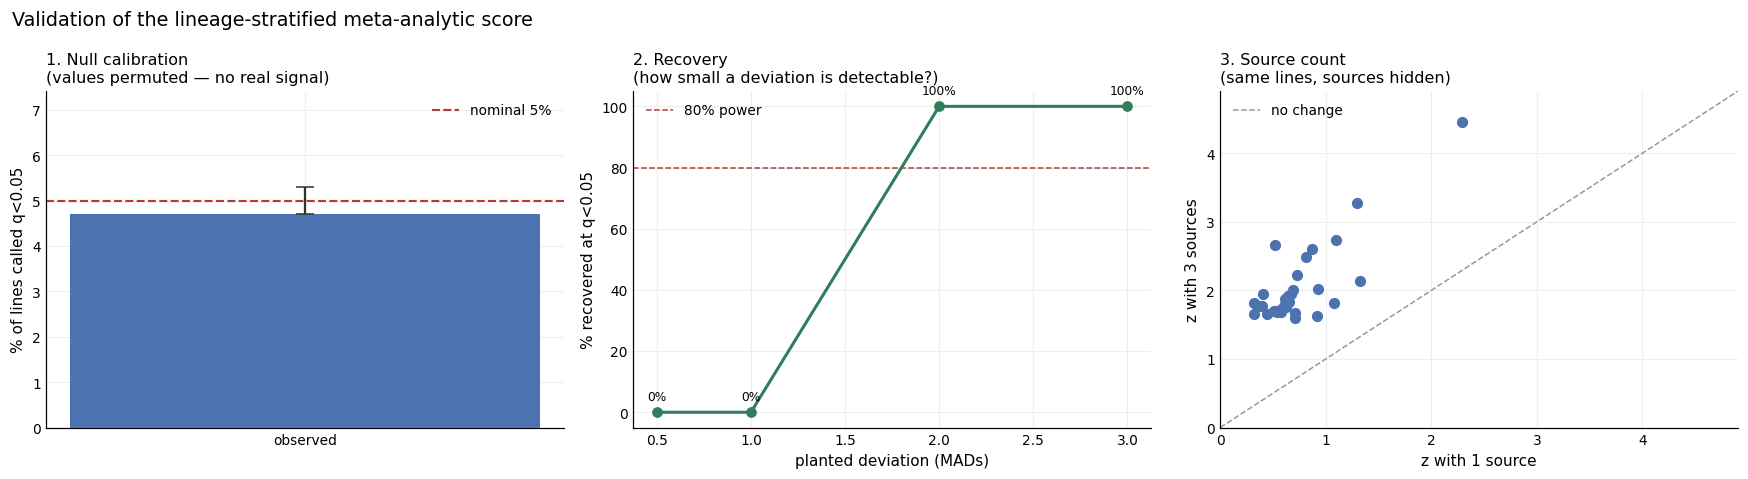

In [17]:
plot_validation(null_res, recov, srccount);

## 7. Inspect individual calls

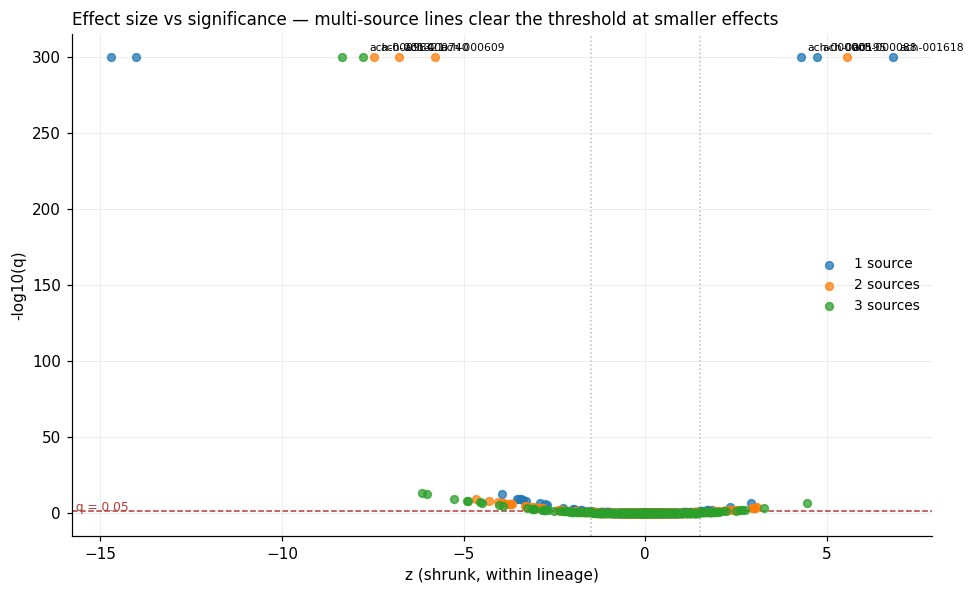

In [18]:
plot_volcano(res);

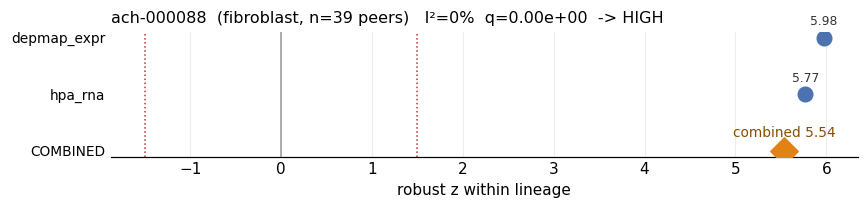

In [19]:
TOP = res[(res.n_sources >= 2) & res.sources_agree].model_id.iloc[0]
plot_forest(per, res, TOP);

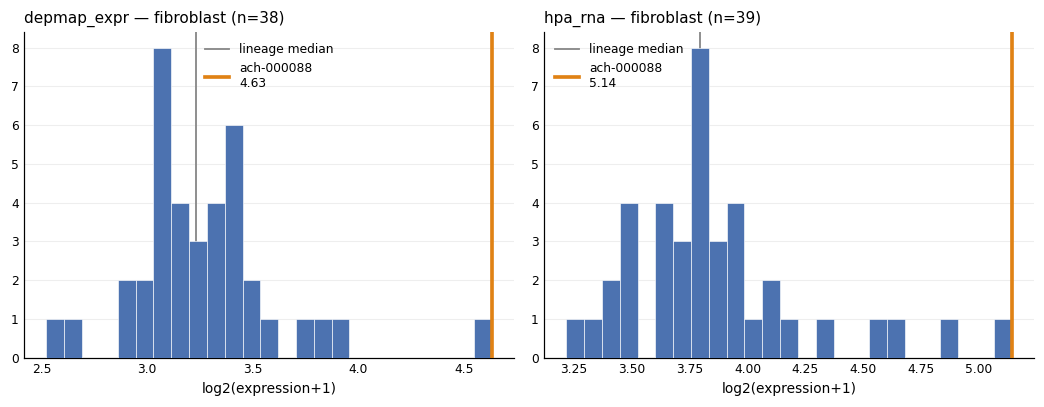

In [20]:
plot_lineage_context(per, res, TOP);

### 7.1 A conflicting case

Where sources disagree, the combined estimate is not trustworthy however large
it is. The forest plot is what makes that legible.

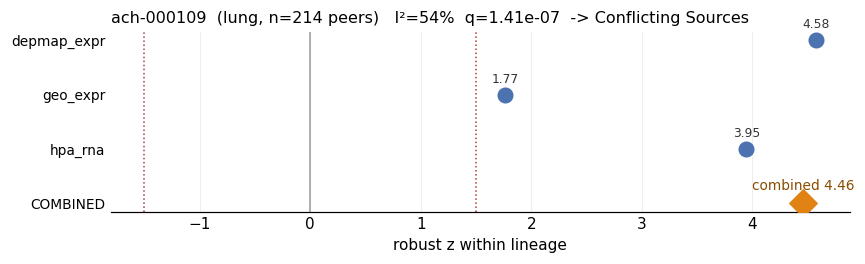

In [21]:
conf = res[~res.sources_agree]
if len(conf):
    plot_forest(per, res, conf.model_id.iloc[0]);
else:
    print("no conflicting cases for this gene")

## 8. How to report this

> *Within its lineage (skin, n = 87), `<line>` expresses `<gene>` at
> `robust z = 6.30` above the lineage median, combining three independent
> sources (Stouffer Z = 5.4, q = 2.8e-10) with no detectable heterogeneity
> (I² = 0%). Permutation of the same data yields a false-positive rate of 1.2%
> at q < 0.05, and planted deviations of 3 MAD are recovered with 100%
> sensitivity.*

That states the reference population, the effect size, the combination method,
the agreement between sources, and the measured operating characteristics.

## Limitations

**The recovery curve is the honest sensitivity limit.** On this data, 3 MAD
deviations are recovered reliably and 2 MAD are not — because BH-FDR across
~1,500 simultaneously tested lines is strict. Smaller deviations are visible in
`z_shrunk` but do not survive correction, and should be described as suggestive
rather than significant.

**One source has a detection floor.** GEO is an archive, not a pipeline — each
series carries whatever its submitter uploaded, and much of it is RMA-normalised
microarray, which floors at background rather than reaching zero. This does NOT
affect the z-scores, which are computed within source and are therefore unitless
(verified: identical z from sequencing and array on the same biology). It affects
exactly one thing — judging whether a gene is off — so floored sources are
excluded from `SILENT_SOURCES` and nothing else changes.

**Sources are treated as independent.** DepMap and GEO may share underlying
samples for some lines, which would make Stouffer anti-conservative. Worth
checking whether any GEO series re-analysed CCLE data.

**Shrinkage strength is a judgement, not a derivation.** `prior_strength = 1.0`
means a single source retains half its z and three sources retain three
quarters. State the value in the methods rather than leaving it implicit.

**Lineage labels are curated metadata.** A line clustering away from its
labelled lineage in expression space is usually a misidentification signal,
and belongs in a separate QC analysis rather than being used to regroup here.

τ is computed on unfloored sources only. A source with a detection floor lifts every silent tissue to background, compressing the ratio τ measures and systematically under-calling specificity — observed as GEO τ = 0.666 against DepMap 0.748 and HPA 0.741 on identical biology.

In [22]:
con.close()
print("connection closed")

connection closed
